# Interactive Script: **get_stac_layers**

**Author:** Baturalp Arisoy<br>
**Contact:** baturalp.arisoy@uni-wuerzburg.de - Call me Batu

## Overview
This notebook guides the user through the essentials of _stac2cube.get_stac_layers_ function. Besides, further chapters contain examples of how to read, write and process the data cube structure obtained by the function.

## Contents

1. [How to **get_stac_layers**](#1-how-to-get_stac_layers)
2. [Read a NETCDF file](#2-read-a-netcdf-file)
3. [Slice Time and Band](#3-slice-time-and-band)
4. [Calculate Stats](#4-calculate-stats)
5. [Export Data Arrays](#5-export-data-arrays)
6. [Simple Visualization](#6-simple-visualization)
7. [Graphs](#7-graphs)
8. [Time Series Tools](#8-time-series-tools)
9. [Update Existing Data Array](#9-update-existing-data-array)
10. [Batch Processing Features](#10-batch-processing-features)
11. [Examples for Other Missions](#11-examples-for-other-missions)

---

## Import

In [9]:
from stac2cube import get_stac_layers, missions
from stac2cube import interactive_time_view, generate_animation
import xarray as xr
import numpy as np
import dask
from dask.diagnostics import ProgressBar
import rioxarray
import matplotlib.pyplot as plt
import pandas as pd

## 1. How to **get_stac_layers**

### 1.1. Set the parameters

In [2]:
# Have a look at what a parameter can take for the selected mission
missions()

,name,allias,stac_catalog,default_resolution,bands,indices,topographic_features,max_cc,clip_raster,cloud_masking,output,aggregator,stats,update,animation
0,sentinel_2_l2a,s2,https://earth-search.aws.element84.com/v1/,10,"[coastal, blue, green, red, rededge1, rededge2, rededge3, nir, nir08, nir09, swir16, swir22]","[ndvi, ndwi, savi]",False,100,"[True, False]","[True, False]",path/to/output.nc,"[mean, median]","[mean, median, std, min, max]",path/to/stac.nc,"[True, False]"
1,sentinel_2_l1c,s2_l1c,https://earth-search.aws.element84.com/v1/,10,"[coastal, blue, green, red, rededge1, rededge2, rededge3, nir, nir08, nir09, cirrus, swir16, swir22]","[ndvi, ndwi, savi]",False,100,"[True, False]","[True, False]",path/to/output.nc,"[mean, median]","[mean, median, std, min, max]",path/to/stac.nc,"[True, False]"
2,sentinel_1_rtc,s1,https://planetarycomputer.microsoft.com/api/stac/v1,10,"[vh, vv]","[vh/vv, vv/vh, rvi]",False,False,"[True, False]",False,path/to/output.nc,"[mean, median]","[mean, median, std, min, max]",path/to/stac.nc,False
3,landsat_ot_c2_l2,l_oli,https://stac.terrabyte.lrz.de/public/api/,30,"[coastal, blue, green, red, nir, swir1, swir2, thermal]","[ndvi, ndwi, savi]",False,100,"[True, False]","[True, False]",path/to/output.nc,"[mean, median]","[mean, median, std, min, max]",path/to/stac.nc,"[True, False]"
4,cop_dem_glo_30,cop_dem,https://stac.terrabyte.lrz.de/public/api/,False,False,False,"[slope, aspect, d_inf_flow_accumulation, twi]",False,"[True, False]",False,path/to/output.nc,False,False,False,False


In [10]:
mission = "s2"                              # both name and allias work. Can not be None!
polygon = "./polygons/test.gpkg"            # if not available, try optional cell below
resolution = 10                             # if None -> default_resolution
daterange = ["2023-01-01", "2025-01-01"]    # if None -> every available date
bands = ["blue", "green", "red", "nir"]     # if None -> all bands of the relevant mission, but also SCL
max_cc = 100                                # 0-100, if None -> 100
clip_raster = False                         # if None -> False
cloud_masking = False                       # if None -> False
indices = ["ndvi", "ndwi"]                  # if None -> no indices
output = None                               # Will return lazy! To export, replace with path to netcdf.
stats = None                                # if None -> no stats
aggregator = None                           # if None -> no aggregation
animation = False                           # if None -> no animation

#### (Optional) If polygon is not available, select your area below on Leafmap

In [ ]:
# Adjust the extent and execute the NEXT cell. The extent will be bbox.
import leafmap
m = leafmap.Map(center=[49.787281735930804, 9.978161492015976], zoom=18, height="800px")
m

In [ ]:
# This will be take above leafmap view extent as the new polygon. 
bbox = (m.west, m.south, m.east, m.north)
polygon = list(bbox)
polygon

### 1.2. Get Stac Layers, returns lazy xarray.DataArray

In [11]:
stac = get_stac_layers(mission=mission, polygon=polygon, resolution=resolution, 
                            daterange=daterange, bands=bands, max_cc=max_cc, 
                            clip_raster=clip_raster, cloud_masking=cloud_masking, indices=indices, 
                            output=output, aggregator=aggregator, stats=stats,
                            animation=animation)

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 277, band: 6, y: 247, x: 511)> Size: 2GB
dask.array<transpose, shape=(277, 6, 247, 511), dtype=float64, chunksize=(1, 1, 247, 511), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 2kB 4.547e+06 4.547e+06 ... 4.544e+06 4.544e+06
  * x            (x) float64 4kB 6.67e+05 6.67e+05 ... 6.721e+05 6.721e+05
  * band         (band) <U5 120B 'blue' 'green' 'red' 'nir' 'ndvi' 'ndwi'
  * time         (time) datetime64[ns] 2kB 2023-01-02 2023-01-04 ... 2025-01-01
    spatial_ref  int64 8B 0
Attributes:
    indices:         ['ndvi', 'ndwi']
    spectral_bands:  ['blue', 'green', 'red', 'nir']
    mission:         sentinel_2_l2a
    tile_id:         ['35TPF']
    bbox:            [28.98752355404842, 41.03150270425637, 29.04759458831022...
    crs:             WGS 84 / UTM zone 35N
    transform:       | 10.00, 0.00, 667020.00|\n| 0.00,-10.00, 4546620.00|\n|...


**If time coordinate is too long to be printed**

In [8]:
print(stac.time.values)
# Click "View as a scrollable element" below 

2023-01-02T00:00:00.000000000


## 2. Read a NETCDF file

> **Note:**
> STAC layers are stored under dataarray not dataset, however NETCDFs should be read as dataset first.

> **Note 2:**
> If the stac is exported with output and stats are selected, you will have multiple layers. Original Spectral Temporal Stack and the selected stats.

### 2.1 Read NETCDF as dataset

In [12]:
img = ("./results/test.nc")

dataset = xr.open_dataset(img)
dataset

<xarray.Dataset> Size: 24MB
Dimensions:                  (y: 247, x: 511, band: 6, time: 4)
Coordinates:
  * y                        (y) float64 2kB 4.547e+06 4.547e+06 ... 4.544e+06
  * x                        (x) float64 4kB 6.67e+05 6.67e+05 ... 6.721e+05
  * band                     (band) <U5 120B 'blue' 'green' ... 'ndvi' 'ndwi'
  * time                     (time) datetime64[ns] 32B 2024-04-06 ... 2024-04-13
Data variables:
    spatial_ref              int64 8B ...
    Spectral_Temporal_Stack  (time, band, y, x) float64 24MB ...

> **Note:**
> Spectral_Temporal_Stack is where the multi-time and multi-spectral values are stored.
<br><br>
**Select Spectral Temporal Stack as dataarray**

In [14]:
daterange = [min(dataarray.time.values), max(dataarray.time.values)]
daterange = [str(dt) for dt in daterange]
daterange


['2024-04-06T00:00:00.000000000', '2024-04-13T00:00:00.000000000']

In [13]:
dataarray = dataset.Spectral_Temporal_Stack
dataarray

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 4, band: 6, y: 247, x: 511)> Size: 24MB
[3029208 values with dtype=float64]
Coordinates:
  * y        (y) float64 2kB 4.547e+06 4.547e+06 ... 4.544e+06 4.544e+06
  * x        (x) float64 4kB 6.67e+05 6.67e+05 6.67e+05 ... 6.721e+05 6.721e+05
  * band     (band) <U5 120B 'blue' 'green' 'red' 'nir' 'ndvi' 'ndwi'
  * time     (time) datetime64[ns] 32B 2024-04-06 2024-04-08 ... 2024-04-13
Attributes:
    indices:         ['ndvi', 'ndwi']
    spectral_bands:  ['blue', 'green', 'red', 'nir']
    mission:         sentinel_2_l2a
    tile_id:         35TPF
    bbox:            [28.98752355 41.0315027  29.04759459 41.0525646 ]
    crs:             WGS 84 / UTM zone 35N
    transform:       [ 1.00000e+01  0.00000e+00  6.67020e+05  0.00000e+00 -1....
    grid_mapping:    spatial_ref

### 2.2 Read different stats from exported NETCDF

> **Note:**
> If STAC is exported with option **stats**, each stat is stored as seperate data array.

In [ ]:
img = ("/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/narny_2024.nc")

dataset = xr.open_dataset(img)
dataset

In [ ]:
dataarray_mean = dataset.mean_imagery
dataarray_mean

**Bonus: Print mean values of selected band/index per year (requires computation)**

In [ ]:
band = "ndvi"

selected_band = dataset.sel(band=band)
selected_band['year'] = selected_band.time.dt.year
selected_band_per_year = selected_band.groupby('year').mean()

for year in selected_band_per_year['year'].values:
    mean_value = selected_band_per_year.sel(year=year)
    print(f"mean {band} of {year} = {mean_value.mean().values:.4f}")

## 3. Slice Time and Band

### 3.1. Slice Time

#### 3.1.1 Slice Single Date

**By exact date**

In [8]:
date = "2024-10-03"
stac_date = stac.sel(time=date)[0]

**Or by the index**

In [21]:
index = 0
stac_date = stac.isel(time=index)

In [ ]:
stac_date

#### 3.1.2 Slice Time Range

In [ ]:
daterange = ["2024-01-01", "2024-12-31"]
stac_2024 = stac.sel(time=slice(*daterange))
stac_2024

#### 3.1.3 Slice Multiple Dates

In [ ]:
dates = ['2023-01-02', '2024-12-02', '2024-12-24']
stac_dates = stac.sel(time=dates)
stac_dates

### 3.2. Slice Bands

#### 3.2.1 Slice Single Band

In [ ]:
band = 'ndvi'
stac_ndvi = stac.sel(band=band)
stac_ndvi

#### 3.2.2 Slice Multiple Bands

In [ ]:
bands = ['red', 'green', 'blue']
stac_rgb = stac.sel(band=bands)
stac_rgb

### 3.3 Slice both Time and Band

In [ ]:
daterange = ["2024-01-01", "2024-12-31"]
bands = ['red', 'green', 'blue']

stac_2024 = stac.sel(time=slice(*daterange))
stac_2024_rgb = stac_2024.sel(band=bands)
stac_2024_rgb

## 4. Calculate Stats

**Some stat calculations can be done prior to compute**

### 4.1 Calculate a single stat for a given daterange

In [ ]:
daterange = ["2024-01-01", "2024-12-31"]
stac_2024 = stac.sel(time=slice(*daterange))
stac_2024_mean = stac_2024.mean(dim='time')
stac_2024_mean

### 4.2 Calculate selected stats for a given daterange

In [9]:
daterange = ["2024-01-01", "2024-12-31"]
stac_2024 = stac.sel(time=slice(*daterange))

stats = ['mean', 'median', 'std', 'max', 'min']
stac_2024_stats = {stat: getattr(stac_2024, stat)(dim='time') for stat in stats}

**Select desired stat**

In [ ]:
stac_2024_stats['median']

## 5. Export Data Arrays

### 5.1 Export as NETCDF

In [12]:
daterange = ["2024-04-04", "2024-04-10"]
stac_sel = stac.sel(time=slice(*daterange))

if dask.is_dask_collection(stac_sel):
    with ProgressBar():
        img = stac_sel.compute()

img.to_netcdf("./results/test.nc")

[########################################] | 100% Completed | 6.86 ss


> **Note:**
> If the process takes too long and eventually fails due to unsufficient memory, you can select narrower date range then use updating mechanism, see Chapter 9.<br><br>
With updating mechanism, for example, instead of computing 8 years of data, update every year range seperately.<br><br>
The problem is not with exporting itself but computation of arrays, therefore, splitting computations is a good strategy if the local machine is not strong enough. So, divide and conquer ;)

### 5.2 Export as Cloud Optimized Geotifs (COGs)

> **Note:**
> Geotiff format cannot handle 4 dimensional system. Therefore each time has to be exported separately.

In [5]:
stac_cog = stac_sel.to_dataset(dim='band')
output_dir = './results/cogs/'

for i in range(len(stac_cog.time)):
    single_timestamp = stac_cog.isel(time=i)
    date_str = str(single_timestamp.time.values)[:10]
    print(f'Writing {date_str}')
    output_file = f'{output_dir}{date_str}.tif'    
    single_timestamp.rio.to_raster(output_file, driver='COG', dtype='float32', compress='deflate')

Writing 2024-04-06
Writing 2024-04-08
Writing 2024-04-11


## 6. Simple Visualization

> **Note:**
> Simple visualization can be done on lazy returned array, making Dask great for simple analysis without demanding processing.

**Run normalization function for better results, otherwise images will be very dark**

In [29]:
def normalize(band, clip_percentile=2):
    band_min, band_max = np.nanpercentile(band, [clip_percentile, 100 - clip_percentile])
    if band_max == band_min:
        return np.zeros_like(band)
    band = np.clip(band, band_min, band_max)
    normalized = (band - band_min) / (band_max - band_min)
    normalized = np.nan_to_num(normalized, nan=0.5)
    return normalized

### 6.1 RGB Visualization of a selected date

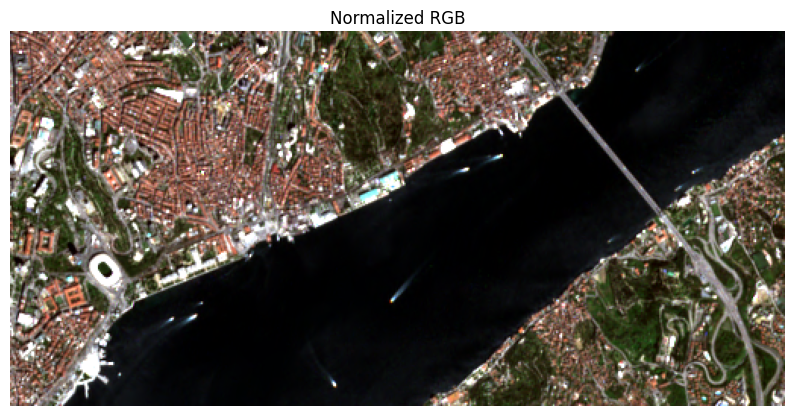

In [33]:
time_to_visualize = '2024-04-06'
bands = ["red", "green", "blue"]

da_time = stac.sel(time=time_to_visualize)
da_composite = da_time.sel(band=bands)

band1 = da_composite[0]
band1_normalized = normalize(band = band1)
band2 = da_composite[1]
band2_normalized = normalize(band = band2)
band3 = da_composite[2]
band3_normalized = normalize(band = band3)
composite = np.dstack((band1_normalized, band2_normalized, band3_normalized))

# Plot the image
plt.figure(figsize=(10, 5))
plt.imshow(composite)
plt.title("Normalized RGB")
plt.axis("off")
plt.show()

### 6.2 NDVI Visualization

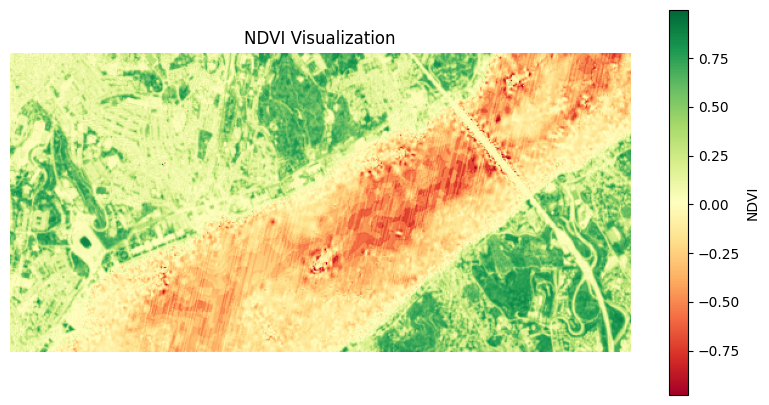

In [34]:
time_to_visualize = '2024-04-06'
ndvi_band = "ndvi"

da_time = stac.sel(time=time_to_visualize)
da_ndvi = da_time.sel(band=ndvi_band)
ndvi_data = da_ndvi.values

plt.figure(figsize=(10, 5))
plt.imshow(ndvi_data, cmap="RdYlGn")
plt.colorbar(label="NDVI")
plt.title("NDVI Visualization")
plt.axis("off")
plt.show()

### 6.3 Other Examples

**False Coloring**

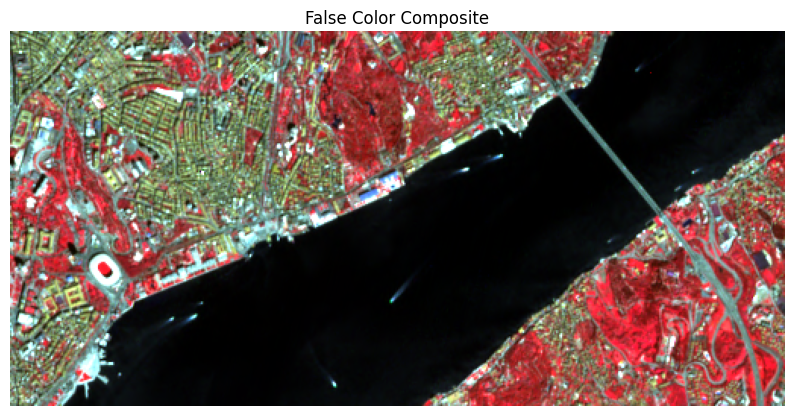

In [37]:
time_to_visualize = '2024-04-06'
bands = ["nir", "red", "green"]

da_time = stac.sel(time=time_to_visualize)
da_composite = da_time.sel(band=bands)

band1 = da_composite[0]
band1_normalized = normalize(band = band1)
band2 = da_composite[1]
band2_normalized = normalize(band = band2)
band3 = da_composite[2]
band3_normalized = normalize(band = band3)
composite = np.dstack((band1_normalized, band2_normalized, band3_normalized))

# Plot the image
plt.figure(figsize=(10, 5))
plt.imshow(composite)
plt.title("False Color Composite")
plt.axis("off")
plt.show()

**NDWI**

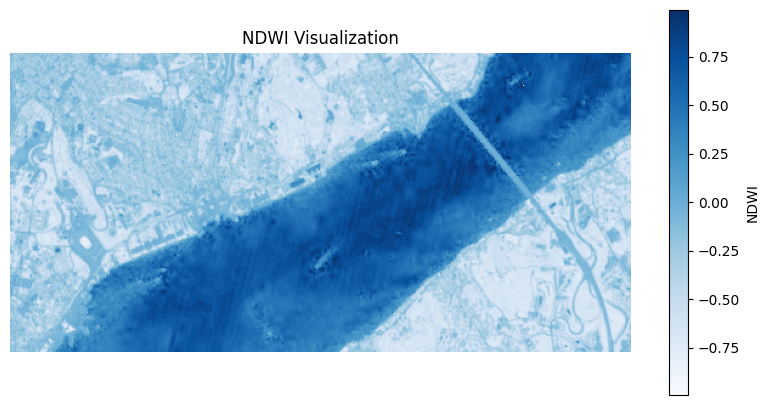

In [39]:
time_to_visualize = '2024-04-06'
ndwi_band = "ndwi"

da_time = stac.sel(time=time_to_visualize)
da_ndwi = da_time.sel(band=ndwi_band)
ndwi_data = da_ndwi.values

plt.figure(figsize=(10, 5))
plt.imshow(ndwi_data, cmap="Blues")
plt.colorbar(label="NDWI")
plt.title("NDWI Visualization")
plt.axis("off")
plt.show()

## 7. Graphs

### 7.1 Time Series Graph

> **Note:**
> Following mean calculation over x and y coordinates requires **computation**. Therefore, if stac is lazy array, then it will take time. For faster experience, export with SLURM, then read NETCDF file and get Spectral Temporal Stack.

In [2]:
ds = xr.open_dataset("/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/orog_1_noclip.nc")
da = ds.Spectral_Temporal_Stack

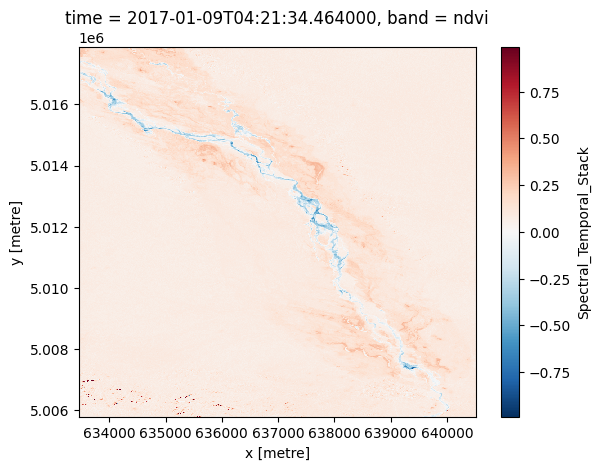

In [3]:
da[0][4].plot()

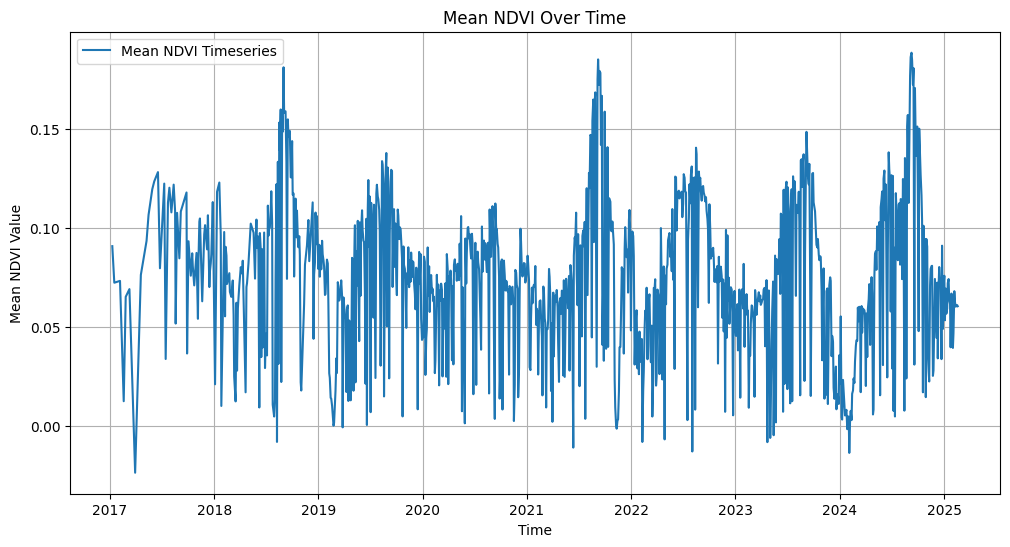

In [4]:
band = "ndvi"

da_sel = da.sel(band=band)
da_sel = da_sel.mean(dim=["x", "y"])

# Plot the values over time
plt.figure(figsize=(12, 6))
plt.plot(da_sel["time"], da_sel, label="Mean NDVI Timeseries")
plt.xlabel("Time")
plt.ylabel("Mean NDVI Value")
plt.title("Mean NDVI Over Time")
plt.legend()
plt.grid()
plt.show()

**Smoothed series**

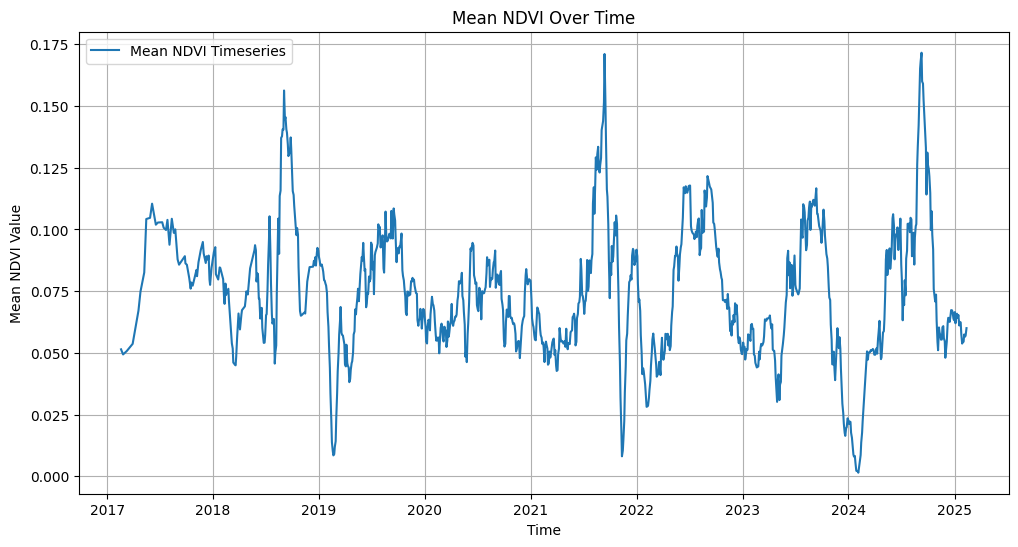

In [5]:
smoothed_da = da_sel.rolling(time=7, center=True).mean()
plt.figure(figsize=(12, 6))
plt.plot(smoothed_da["time"], smoothed_da, label="Mean NDVI Timeseries")
plt.xlabel("Time")
plt.ylabel("Mean NDVI Value")
plt.title("Mean NDVI Over Time")
plt.legend()
plt.grid()
plt.show()

### 7.2 Export Time Series as CSV

In [4]:
# Select bands/indices, stats and export path
da = da.sel(band=["ndvi", "ndwi"])
stats = ["mean", "median"]
export_path = "./results/timeseries.csv"

bands = da.coords['band'].values
df_list = []
for band in bands:
    da_band = da.sel(band=band)
    base_stat = stats[0]
    df_band = getattr(da_band, base_stat)(dim=["x", "y"]).to_dataframe(name=base_stat).reset_index()[["time"]]
    df_band["band"] = band
    for stat in stats:
        df_band[stat] = getattr(da_band, stat)(dim=["x", "y"]).values
    df_band["time"] = df_band["time"].dt.date  
    df_list.append(df_band)

df_all = pd.concat(df_list, ignore_index=True)
df_all = df_all.sort_values(by=["time", "band"])
df_all.to_csv(export_path, index=False)

### 7.3 (Multi)Seasonal-Trend decomposition using LOESS

In [7]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import MSTL

In [28]:
da_sel

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 1034)> Size: 8kB
array([0.09079285, 0.07235902, 0.0732902 , ..., 0.06055129, 0.06105204,
       0.06049898], shape=(1034,))
Coordinates:
    band     <U5 20B 'ndvi'
  * time     (time) datetime64[ns] 8kB 2017-01-09 2017-01-16 ... 2025-02-18

In [22]:
# 1. Select the 'ndvi' band and average over spatial dimensions (x, y)
da_sel = da.sel(band="ndvi").mean(dim=["x", "y"])
da_sel['time'] = da_sel['time'].dt.floor('D')

# 2. Convert the xarray DataArray to a Pandas Series
#    The Pandas Series will have a DatetimeIndex derived from the 'time' dimension.
ts = da_sel.to_series()

# 3. Resample the data to a regular daily frequency and fill gaps with linear interpolation.
#    This step is crucial because MSTL expects data with a constant time step.
ts_reg = ts.resample('D').interpolate(method='linear')

# 4. Define seasonal periods.
#    - Monthly: ~30 days (approximation)
#    - Quarterly: ~90 days (3 months)
#    - Annual: ~365 days (1 year)
seasonal_periods = [30, 90, 365]

In [24]:
ts_reg

time
2017-01-09    0.090793
2017-01-10    0.088159
2017-01-11    0.085526
2017-01-12    0.082893
2017-01-13    0.080259
                ...   
2025-02-14    0.060718
2025-02-15    0.060885
2025-02-16    0.061052
2025-02-17    0.060776
2025-02-18    0.060499
Freq: D, Name: Spectral_Temporal_Stack, Length: 2963, dtype: float64

In [61]:
mstl_result = MSTL(ts, periods=seasonal_periods).fit()

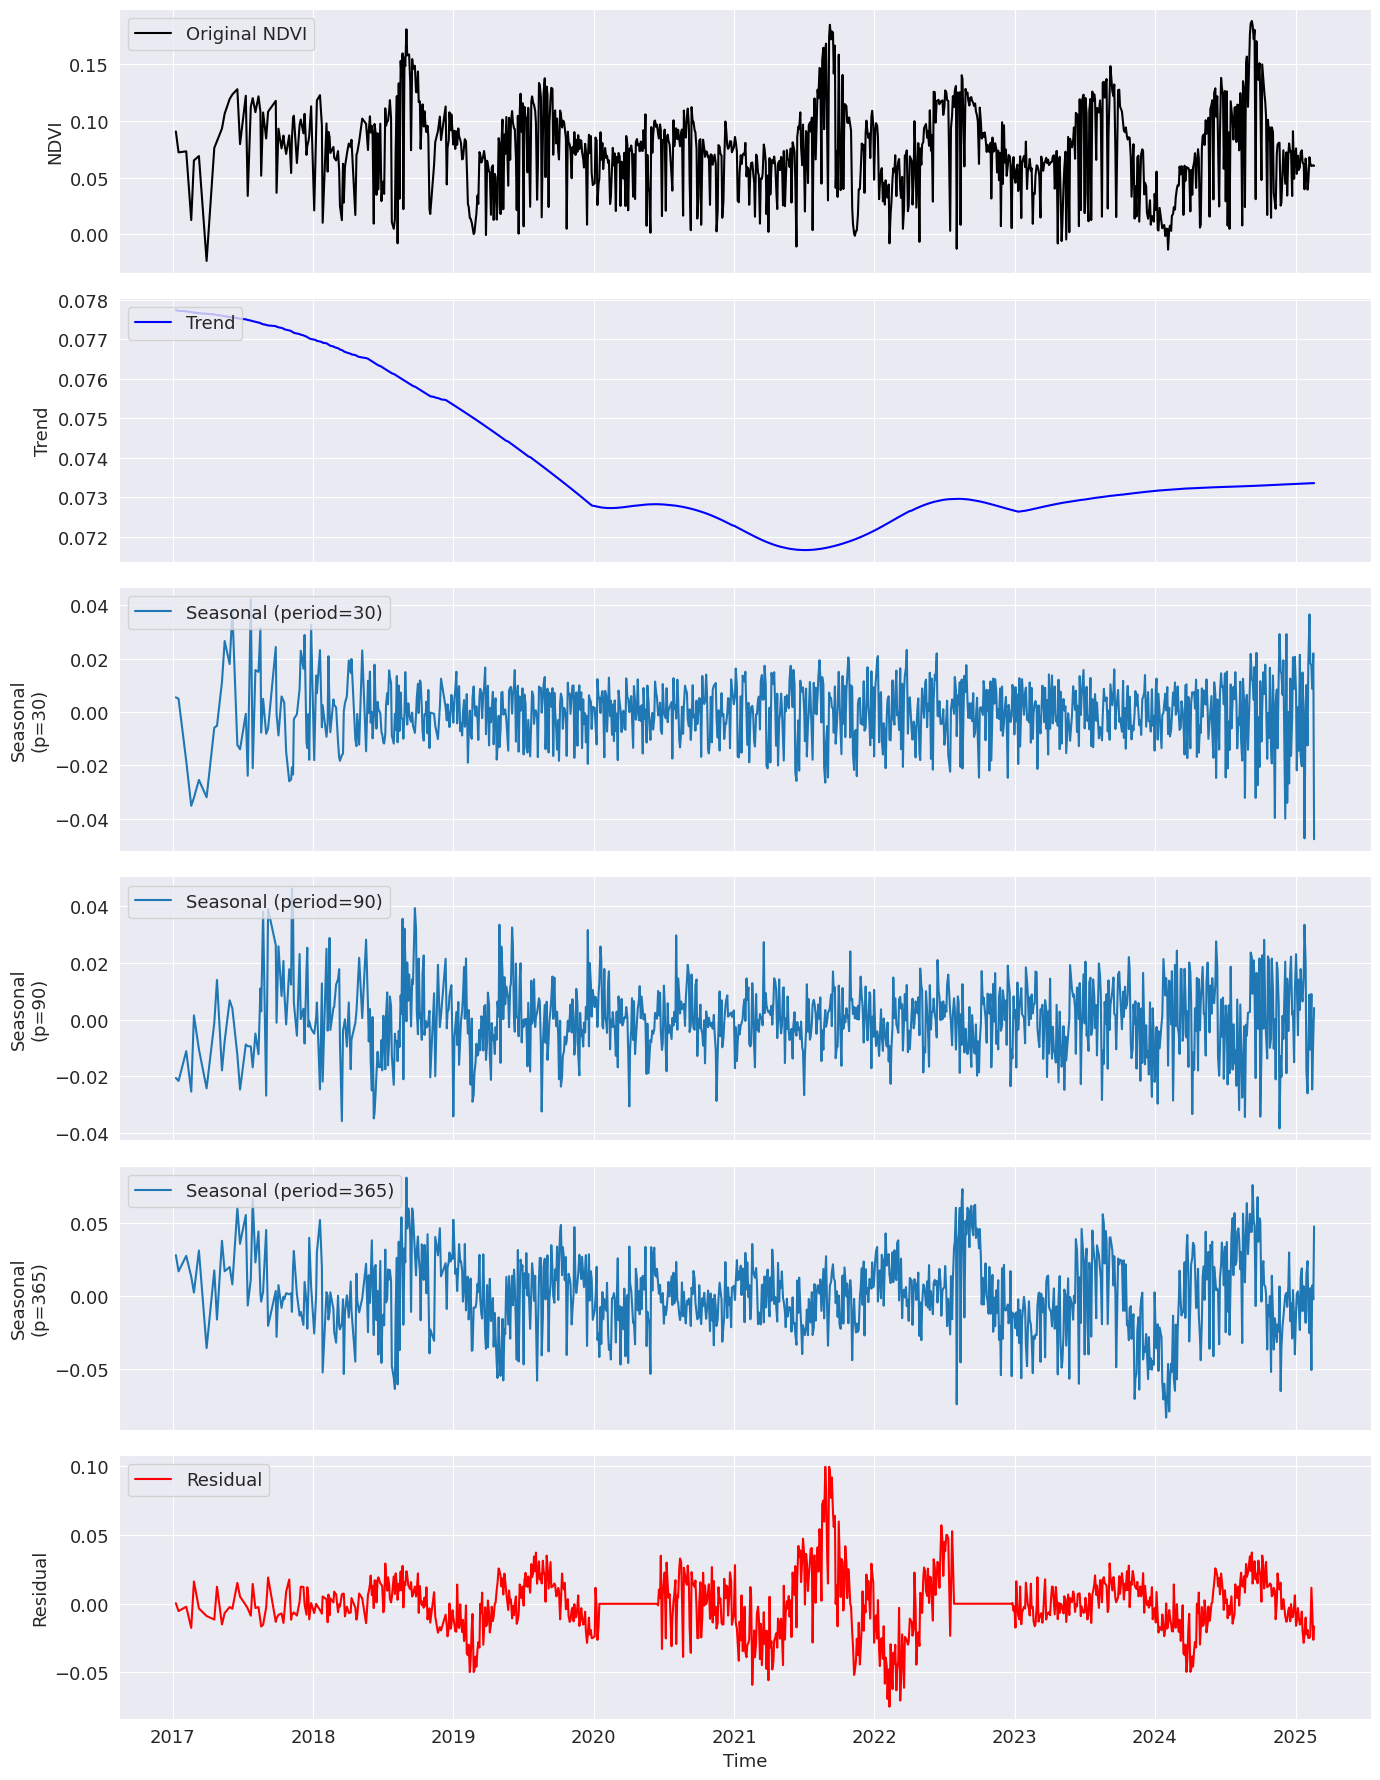

In [62]:
import matplotlib.pyplot as plt

n_seasons = len(seasonal_periods)

# Allocate 3+n_seasons subplots: original, trend, one for each season, and one for residuals.
fig, axs = plt.subplots(3 + n_seasons, 1, figsize=(14, 3*(3 + n_seasons)), sharex=True)

# 1. Plot original NDVI timeseries
axs[0].plot(ts_reg, label='Original NDVI', color='black')
axs[0].set_ylabel("NDVI")
axs[0].legend(loc='upper left')
axs[0].grid(True)

# 2. Plot trend component
axs[1].plot(mstl_result.trend, label='Trend', color='blue')
axs[1].set_ylabel("Trend")
axs[1].legend(loc='upper left')
axs[1].grid(True)

# 3. Plot each seasonal component separately
for i, period in enumerate(seasonal_periods):
    seasonal_component = mstl_result.seasonal.iloc[:, i]
    axs[2 + i].plot(seasonal_component, label=f'Seasonal (period={period})')
    axs[2 + i].set_ylabel(f'Seasonal\n(p={period})')
    axs[2 + i].legend(loc='upper left')
    axs[2 + i].grid(True)

# 4. Plot residuals in the last subplot
axs[-1].plot(mstl_result.resid, label='Residual', color='red')
axs[-1].set_ylabel("Residual")
axs[-1].legend(loc='upper left')
axs[-1].grid(True)

# Final layout adjustments
plt.xlabel("Time")
plt.tight_layout()
plt.show()


In [41]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pandas.plotting import register_matplotlib_converters

register_matplotlib_converters()
sns.set_style("darkgrid")

In [42]:
plt.rc("figure", figsize=(16, 12))
plt.rc("font", size=13)

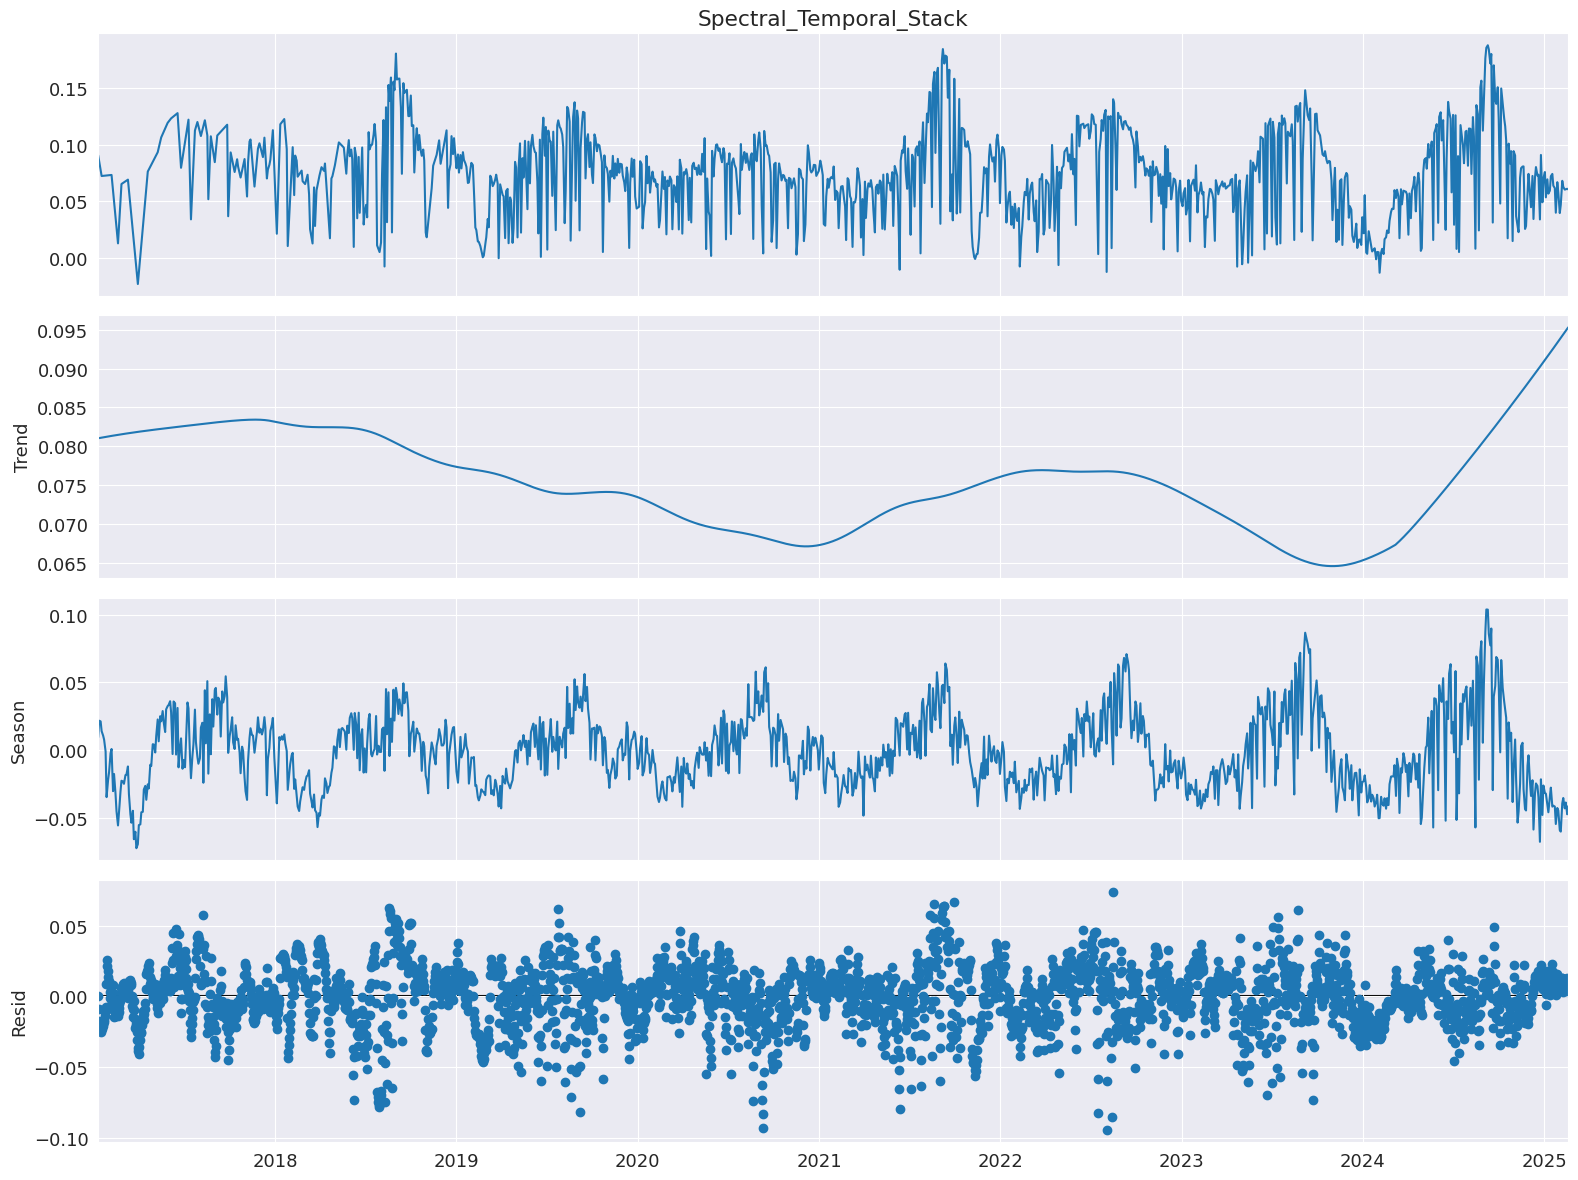

In [63]:
from statsmodels.tsa.seasonal import STL

stl = STL(ts_reg, period=365)
res = stl.fit()
fig = res.plot()

## 8. Time Series Tools

> **Note:**
> Time series tools can be applied to lazy stacs. The performance of widgets will be based on user's local machine instead of terrabyte cluster.

In [6]:
# Select the range of the time series
daterange = ["2024-07-01", "2024-07-30"]
stac_timeseries = stac.sel(time=slice(*daterange))

In [6]:
#OR
stac = xr.open_dataset("./results/test.nc")
stac_timeseries = stac.Spectral_Temporal_Stack

### 8.1 Interactive Time View

> **Note:**
> Display mode options: 'rgb', 'ndvi', 'ndwi'

#### 8.1.1 Slider

In [7]:
interactive_time_view(stac=stac_timeseries, display_mode='rgb', widget_type='slider')

interactive(children=(IntSlider(value=0, description='Time', layout=Layout(width='800px'), max=11), Output()),…

#### 8.1.2 Dropdown

In [15]:
interactive_time_view(stac=stac_timeseries, display_mode='ndvi', widget_type='dropdown')

interactive(children=(Dropdown(description='Date:', layout=Layout(width='300px'), options=(('09-01-2017', 0), …

### 8.2 Animation

Skipping plot for 20240327_000000 due to missing data.


MovieWriter imagemagick unavailable; using Pillow instead.


Number of images: 145


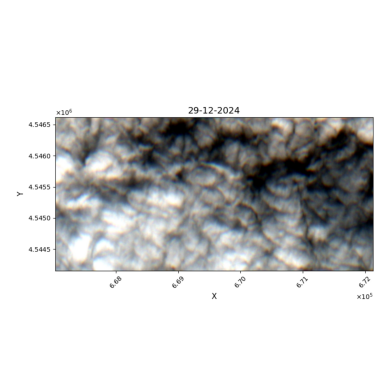

In [10]:
output_folder = "./animations/"
display_mode = "rgb" # Animation could be one of the following: "rgb", "ndvi" "ndwi"

generate_animation(stac=stac_timeseries, export_folder=output_folder, display_mode=display_mode)

## 9. Update Existing Data Array

### 9.1 Read the existing STAC

In [2]:
img = ("./results/test.nc")
dataset = xr.open_dataset(img)
stac = dataset.Spectral_Temporal_Stack
stac

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 8, band: 6, y: 247, x: 511)> Size: 48MB
[6058416 values with dtype=float64]
Coordinates:
  * y        (y) float64 2kB 4.547e+06 4.547e+06 ... 4.544e+06 4.544e+06
  * x        (x) float64 4kB 6.67e+05 6.67e+05 6.67e+05 ... 6.721e+05 6.721e+05
  * band     (band) <U5 120B 'blue' 'green' 'red' 'nir' 'ndvi' 'ndwi'
  * time     (time) datetime64[ns] 64B 2024-04-01 2024-04-03 ... 2024-04-18
Attributes:
    indices:         ['ndvi', 'ndwi']
    spectral_bands:  ['blue', 'green', 'red', 'nir']
    mission:         sentinel_2_l2a
    tile_id:         35TPF
    bbox:            [28.98752355 41.0315027  29.04759459 41.0525646 ]
    crs:             WGS 84 / UTM zone 35N
    transform:       [ 1.00000e+01  0.00000e+00  6.67020e+05  0.00000e+00 -1....
    grid_mapping:    spatial_ref

In [3]:
stac.time.values

array(['2024-04-01T00:00:00.000000000', '2024-04-03T00:00:00.000000000',
       '2024-04-06T00:00:00.000000000', '2024-04-08T00:00:00.000000000',
       '2024-04-11T00:00:00.000000000', '2024-04-13T00:00:00.000000000',
       '2024-04-16T00:00:00.000000000', '2024-04-18T00:00:00.000000000'],
      dtype='datetime64[ns]')

### 9.2 Select parameters

> **Note:**
> Following parameters will be overwritten. Therefore, they don't have to be part of updating mechanism, but even if they do, won't have any effect: **mission, resolution, polygon, bands, indices, output**

In [4]:
update = "./results/test.nc"
daterange = ["2024-04-01", "2024-04-23"]
max_cc = 100
clip_raster = False
cloud_masking = False
stats = None
aggregator = None
animation = False

### 9.3 Update STAC

In [5]:
stac = get_stac_layers(update=update, daterange=daterange,
                        max_cc=max_cc, clip_raster=clip_raster,
                        cloud_masking=cloud_masking,
                        stats=stats, aggregator=aggregator,
                        animation=animation, q=True)

2 new dates found!
Update Report:
-------------------------
2 new dates have been integrated into the dataset.
The following dates were added:
 - 2024-04-21
 - 2024-04-23
-------------------------
Export is done: ./results/test.nc


In [ ]:
stac

In [27]:
stac.time.values

array(['2024-04-01T00:00:00.000000000', '2024-04-03T00:00:00.000000000',
       '2024-04-06T00:00:00.000000000', '2024-04-08T00:00:00.000000000',
       '2024-04-11T00:00:00.000000000', '2024-04-13T00:00:00.000000000'],
      dtype='datetime64[ns]')

## 10. Batch Processing Features

### 10.1 Multi Stac Layers

When a polygon with multiple features is given, the function generates data cubes per each feature in the polygon seperately.

> **Note:**
> - Only works with a polygon file with multiple features.
> - Not "multi-polygon" but regular polygon with multiple features.
> - Updating does not work with this function. See 10.2 for multi update.

In [1]:
from stac2cube import multi_stac_layers

In [4]:
polygon = "./polygons/three_polygons.gpkg"     # Can not be None.
output_path = "./results/multi_stacks/"        # Folder that will store multi exported netcdf data cubes
mission = "s2"   
resolution = 10                             
daterange = ["2024-07-01", "2024-07-15"]    
bands = ["blue", "green", "red", "nir"]     
max_cc = 100                                
clip_raster = False                         
cloud_masking = False                       
indices = ["ndvi", "ndwi"]                                                
stats = None                                
aggregator = None
q = True                                       # If None or False -> prints xarray per each feature                

In [5]:
multi_stac_layers(output_path=output_path, polygon=polygon, mission=mission, 
                    resolution=resolution, daterange=daterange, bands=bands, 
                        max_cc=max_cc, clip_raster=clip_raster, cloud_masking=cloud_masking, 
                            indices=indices, stats=stats, aggregator=aggregator, q=q)

1/3 is being computed.
[########################################] | 100% Completed | 11.81 s
Export is done: ./results/multi_stacks/stack_0.nc
2/3 is being computed.
[########################################] | 100% Completed | 14.91 s
Export is done: ./results/multi_stacks/stack_1.nc
3/3 is being computed.
[########################################] | 100% Completed | 10.78 s
Export is done: ./results/multi_stacks/stack_2.nc


### 10.2 Multi Stac Update

The function applies updating mechanism for a list of given netcdf files

> **Note:**
> - Both stac and cloud layers can be included at the same time
> - Some parameters are for get_stac_layer and some for get_cloud_layers but they work together.
> - You don't need to delete any of the parameters :)
> - For now, does not update masked stac :(

In [6]:
from stac2cube import multi_stac_update

In [8]:
# Common updating parameters
update_list = ["./results/test.nc", "./results/test_cloud.nc"]      # Both stac and cloud layers can be included at the same time
daterange = ["2024-04-01", "2024-04-15"]
clip_raster = False 
q = True

# Parameters for get_stac_layers
max_cc = 100                                                                                                       
cloud_masking = False                                               
stats = None                        
aggregator = None

# Parameters for get_cloud_layers
threshold = [70, 80, 90]
#masking

In [ ]:
multi_stac_update(update_list=update_list, daterange=daterange,
                    max_cc=max_cc, clip_raster=clip_raster,
                    cloud_masking=cloud_masking,
                    stats=stats, aggregator=aggregator,
                    threshold=threshold, q=q)

## 11. Examples for Other Missions

### 11.1 Sentinel-1

In [3]:
missions().iloc[2]

name                                                         sentinel_1_rtc
allias                                                                   s1
stac_catalog            https://planetarycomputer.microsoft.com/api/stac/v1
default_resolution                                                       10
bands                                                              [vh, vv]
indices                                                 [vh/vv, vv/vh, rvi]
topographic_features                                                  False
max_cc                                                                False
clip_raster                                                   [True, False]
cloud_masking                                                         False
output                                                    path/to/output.nc
aggregator                                                   [mean, median]
stats                                         [mean, median, std, min, max]
update      

In [2]:
mission = "s1"                              # both name and allias work. Can not be None!
polygon = "./polygons/test.gpkg"            
resolution = 10                             
daterange = ["2023-01-01", "2025-01-01"]    
bands = ["vh", "vv"]
indices = ["vh/vv", "vv/vh", "rvi"]
output = None    
clip_raster = False                                                    
stats = None                                
aggregator = None

In [3]:
stac = get_stac_layers(mission=mission, polygon=polygon, resolution=resolution, 
                            daterange=daterange, bands=bands,
                            clip_raster=clip_raster, indices=indices, 
                            output=output, aggregator=aggregator, stats=stats,
                        )

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 173, band: 5, y: 247, x: 511)> Size: 437MB
dask.array<transpose, shape=(173, 5, 247, 511), dtype=float32, chunksize=(1, 1, 247, 511), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 2kB 4.547e+06 4.547e+06 ... 4.544e+06 4.544e+06
  * x            (x) float64 4kB 6.67e+05 6.67e+05 ... 6.721e+05 6.721e+05
    orbit_state  (time) <U10 7kB 'descending' 'descending' ... 'ascending'
  * band         (band) <U5 100B 'vh' 'vv' 'vh/vv' 'vv/vh' 'rvi'
  * time         (time) datetime64[ns] 1kB 2023-01-01 2023-01-06 ... 2024-12-27
    spatial_ref  int64 8B 0
Attributes:
    indices:         ['vh/vv', 'vv/vh', 'rvi']
    spectral_bands:  ['vh', 'vv']
    mission:         sentinel_1_rtc
    bbox:            [28.98752355404842, 41.03150270425637, 29.04759458831022...
    crs:             WGS 84 / UTM zone 35N
    transform:       | 10.00, 0.00, 667020.00|\n| 0.00,-10.00, 4546620.00|\n|...


#### Plot Map

In [42]:
def normalize(band, clip_percentile=2):
    band_min, band_max = np.nanpercentile(band, [clip_percentile, 100 - clip_percentile])
    if band_max == band_min:
        return np.zeros_like(band)
    band = np.clip(band, band_min, band_max)
    normalized = (band - band_min) / (band_max - band_min)
    normalized = np.nan_to_num(normalized, nan=0.5)
    return normalized

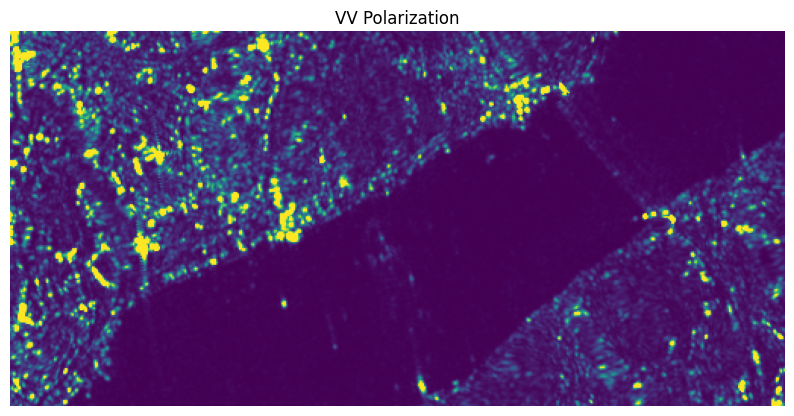

In [49]:
time_to_visualize = '2024-12-27'
bands = ["vv"]

da_time = stac.sel(time=time_to_visualize)
da_composite = da_time.sel(band=bands)
band1 = da_composite[0]
band1_normalized = normalize(band = band1)

# Plot the image
plt.figure(figsize=(10, 5))
plt.imshow(band1_normalized)
plt.title("VV Polarization")
plt.axis("off")
plt.show()

#### Select by orbit-state

In [50]:
orbit_state = "ascending"

stac_ascending = stac.where(stac.orbit_state == orbit_state, drop=True)
stac_ascending

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 56, band: 5, y: 247, x: 511)> Size: 141MB
dask.array<where, shape=(56, 5, 247, 511), dtype=float32, chunksize=(1, 1, 247, 511), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 2kB 4.547e+06 4.547e+06 ... 4.544e+06 4.544e+06
  * x            (x) float64 4kB 6.67e+05 6.67e+05 ... 6.721e+05 6.721e+05
    orbit_state  (time) <U10 2kB 'ascending' 'ascending' ... 'ascending'
  * band         (band) <U5 100B 'vh' 'vv' 'vh/vv' 'vv/vh' 'rvi'
  * time         (time) datetime64[ns] 448B 2023-01-07 2023-01-19 ... 2024-12-27
    spatial_ref  int64 8B 0
Attributes:
    indices:         ['vh/vv', 'vv/vh', 'rvi']
    spectral_bands:  ['vh', 'vv']
    mission:         sentinel-1-rtc
    bbox:            [28.98752355404842, 41.03150270425637, 29.04759458831022...
    crs:             WGS 84 / UTM zone 35N
    transform:       | 10.00, 0.00, 667020.00|\n| 0.00,-10.00, 4546620.00|\n|...

In [56]:
orbit_state = "descending"

stac_descending = stac.where(stac.orbit_state == orbit_state, drop=True)
stac_descending

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 117, band: 5, y: 247, x: 511)> Size: 295MB
dask.array<where, shape=(117, 5, 247, 511), dtype=float32, chunksize=(1, 1, 247, 511), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 2kB 4.547e+06 4.547e+06 ... 4.544e+06 4.544e+06
  * x            (x) float64 4kB 6.67e+05 6.67e+05 ... 6.721e+05 6.721e+05
    orbit_state  (time) <U10 5kB 'descending' 'descending' ... 'descending'
  * band         (band) <U5 100B 'vh' 'vv' 'vh/vv' 'vv/vh' 'rvi'
  * time         (time) datetime64[ns] 936B 2023-01-01 2023-01-06 ... 2024-12-26
    spatial_ref  int64 8B 0
Attributes:
    indices:         ['vh/vv', 'vv/vh', 'rvi']
    spectral_bands:  ['vh', 'vv']
    mission:         sentinel-1-rtc
    bbox:            [28.98752355404842, 41.03150270425637, 29.04759458831022...
    crs:             WGS 84 / UTM zone 35N
    transform:       | 10.00, 0.00, 667020.00|\n| 0.00,-10.00, 4546620.00|\n|...

> **Note:**
> Using **where()** argument breaks the CRS information of the data array. Might visualize with plotting function but will have some issues e.g. when netcdf file is imported to QGIS. Therefore assign the CRS before exporting!

In [58]:
# That's why crs information is embedded as data array attribute
stac_descending = stac_descending.rio.write_crs(stac_descending.crs, inplace=True)
stac_descending.to_netcdf("./results/s1test.nc")

### 11.2 Landsat

In [2]:
missions().iloc[3]

name                                                              landsat_c2_l2
allias                                                                    l_oli
stac_catalog                https://planetarycomputer.microsoft.com/api/stac/v1
default_resolution                                                           30
bands                   [coastal, blue, green, red, nir, swir1, swir2, thermal]
indices                                                      [ndvi, ndwi, savi]
topographic_features                                                      False
max_cc                                                                      100
clip_raster                                                       [True, False]
cloud_masking                                                     [True, False]
output                                                        path/to/output.nc
aggregator                                                       [mean, median]
stats                                   

In [15]:
mission = "l_oli"                              
polygon = "./polygons/test.gpkg"            
resolution = 30                            
daterange = ["2023-01-01", "2025-01-01"]    
bands = ["blue", "green", "red", "nir"]   
max_cc = 100                                
clip_raster = False                        
cloud_masking = False                   
indices = ["ndvi", "ndwi"]                
output = None                               
stats = None                               
aggregator = None                           
animation = False                           

In [16]:
stac = get_stac_layers(mission=mission, polygon=polygon, resolution=resolution, 
                            daterange=daterange, bands=bands, max_cc=max_cc, 
                            clip_raster=clip_raster, cloud_masking=cloud_masking, indices=indices, 
                            output=output, aggregator=aggregator, stats=stats,
                            animation=animation)

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 109, band: 6, y: 83, x: 171)> Size: 74MB
dask.array<transpose, shape=(109, 6, 83, 171), dtype=float64, chunksize=(1, 1, 83, 171), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 664B 4.547e+06 4.547e+06 ... 4.544e+06 4.544e+06
  * x            (x) float64 1kB 6.67e+05 6.671e+05 ... 6.721e+05 6.721e+05
  * band         (band) <U5 120B 'blue' 'green' 'red' 'nir' 'ndvi' 'ndwi'
  * time         (time) datetime64[ns] 872B 2023-01-07 2023-01-15 ... 2024-12-27
    spatial_ref  int64 8B 0
Attributes:
    indices:         ['ndvi', 'ndwi']
    spectral_bands:  ['blue', 'green', 'red', 'nir']
    mission:         landsat_c2_l2
    bbox:            [28.98752355404842, 41.03150270425637, 29.04759458831022...
    crs:             WGS 84 / UTM zone 35N
    transform:       | 30.00, 0.00, 667020.00|\n| 0.00,-30.00, 4546620.00|\n|...


#### Plot Map

In [8]:
def normalize(band, clip_percentile=2):
    band_min, band_max = np.nanpercentile(band, [clip_percentile, 100 - clip_percentile])
    if band_max == band_min:
        return np.zeros_like(band)
    band = np.clip(band, band_min, band_max)
    normalized = (band - band_min) / (band_max - band_min)
    normalized = np.nan_to_num(normalized, nan=0.5)
    return normalized

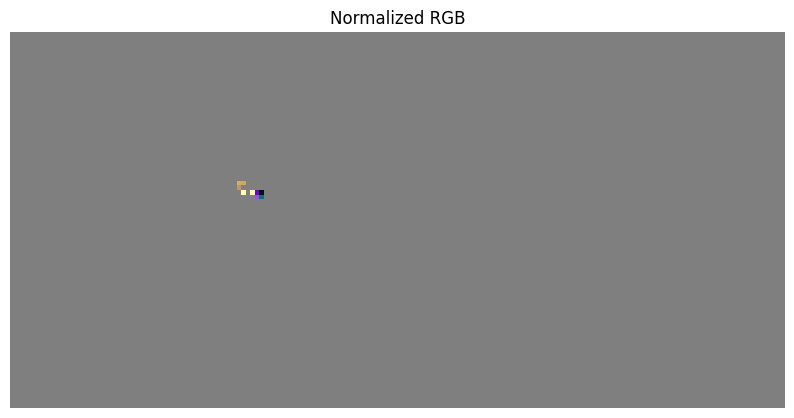

In [11]:
time_to_visualize = '2023-01-31'
bands = ["red", "green", "blue"]

da_time = stac.sel(time=time_to_visualize)
da_composite = da_time.sel(band=bands)

band1 = da_composite[0]
band1_normalized = normalize(band = band1)
band2 = da_composite[1]
band2_normalized = normalize(band = band2)
band3 = da_composite[2]
band3_normalized = normalize(band = band3)
composite = np.dstack((band1_normalized, band2_normalized, band3_normalized))

# Plot the image
plt.figure(figsize=(10, 5))
plt.imshow(composite)
plt.title("Normalized RGB")
plt.axis("off")
plt.show()

### 11.3 COP DEM GLO-30

In [10]:
missions().iloc[4]

name                                                   cop_dem_glo_30
allias                                                        cop_dem
stac_catalog                https://stac.terrabyte.lrz.de/public/api/
default_resolution                                              False
bands                                                           False
indices                                                         False
topographic_features    [slope, aspect, d_inf_flow_accumulation, twi]
max_cc                                                          False
clip_raster                                             [True, False]
cloud_masking                                                   False
output                                              path/to/output.nc
aggregator                                                      False
stats                                                           False
update                                                          False
animation           

In [2]:
mission = "cop_dem"                              
polygon = "./polygons/test.gpkg"                                                                     
clip_raster = False                                                         
output = None
topographic_features = ["slope", "aspect", "d_inf_flow_accumulation", "twi"]                                                                                            

In [3]:
stac = get_stac_layers(mission=mission, polygon=polygon, 
                            clip_raster=clip_raster, 
                            output=output,
                            topographic_features=topographic_features)

APIError: 'utf-8' codec can't decode byte 0xbd in position 1: invalid start byte

In [ ]:
stac